# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test6 probabilities

Notebook equivalent of `tests/4_earth/test6_probabilities.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `earth` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `earth` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing import paths for the editable package.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test6_probabilities"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "4_earth" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\4_earth\test6_probabilities.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `earth` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\earth\test6_probabilities


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_broadcast_mass_weights_helper`

**What is checked:** Broadcast mass weights helper behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Mass weights must broadcast over leading probability dimensions.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [4]:
run_notebook_test(TEST_MODULE.test_broadcast_mass_weights_helper)


Running test_broadcast_mass_weights_helper ...

Broadcast mass weights:
weights shape          : (3,)
probs_i_to_alpha shape : (4, 5, 3, 3)
broadcast weights shape: (1, 1, 3)
------------------------------------------------------------------------------------------
PASSED: test_broadcast_mass_weights_helper


## Test: `test_massbasis_scalar_probabilities_are_normalized`

**What is checked:** Massbasis scalar probabilities are normalized behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Scalar mass-basis output must have shape (3,).

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [5]:
run_notebook_test(TEST_MODULE.test_massbasis_scalar_probabilities_are_normalized)


Running test_massbasis_scalar_probabilities_are_normalized ...

Mass-basis scalar probabilities:
P: tensor([4.2301209885e-01, 3.7832909307e-01, 1.9865880807e-01], dtype=torch.float64)
Checking: Scalar mass-basis probabilities
  P shape       : (3,)
  min/max P     : 0.19865880807251937 0.4230120988529094
  row sums      : tensor(1.0000000000e+00, dtype=torch.float64)
Checking: Scalar mass-basis probabilities: probabilities sum to one
  actual shape  : ()
  expected shape: ()
  max abs diff  : 2.220446e-16
------------------------------------------------------------------------------------------
PASSED: test_massbasis_scalar_probabilities_are_normalized


## Test: `test_flavourbasis_scalar_probabilities_are_normalized`

**What is checked:** Flavourbasis scalar probabilities are normalized behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Scalar flavour-basis output must have shape (3,).

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [6]:
run_notebook_test(TEST_MODULE.test_flavourbasis_scalar_probabilities_are_normalized)


Running test_flavourbasis_scalar_probabilities_are_normalized ...

Flavour-basis scalar probabilities:
P: tensor([8.8399317192e-01, 7.7527170521e-02, 3.8479657558e-02], dtype=torch.float64)
Checking: Scalar flavour-basis probabilities
  P shape       : (3,)
  min/max P     : 0.038479657558431475 0.8839931719202916
  row sums      : tensor(1.0000000000e+00, dtype=torch.float64)
Checking: Scalar flavour-basis probabilities: probabilities sum to one
  actual shape  : ()
  expected shape: ()
  max abs diff  : 0.000000e+00
------------------------------------------------------------------------------------------
PASSED: test_flavourbasis_scalar_probabilities_are_normalized


## Test: `test_above_horizon_identity_limits`

**What is checked:** Above horizon identity limits behavior and numerical consistency.

**Expected result:** The expected result is that the cell completes without raising an exception.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [7]:
run_notebook_test(TEST_MODULE.test_above_horizon_identity_limits)


Running test_above_horizon_identity_limits ...

Above-horizon identity limits:
P_mass          : tensor([6.7504317446e-01, 1.8909836023e-01, 1.3585846531e-01], dtype=torch.float64)
expected mass   : tensor([6.7504317446e-01, 1.8909836023e-01, 1.3585846531e-01], dtype=torch.float64)
P_flavour       : tensor([1.0000000000e+00, 0.0000000000e+00, 0.0000000000e+00], dtype=torch.float64)
expected flavour: tensor([1.0000000000e+00, 0.0000000000e+00, 0.0000000000e+00], dtype=torch.float64)
Checking: Above-horizon mass-basis probabilities reduce to PMNS column
  actual shape  : (3,)
  expected shape: (3,)
  max abs diff  : 0.000000e+00
Checking: Above-horizon flavour-basis probabilities keep the input flavour
  actual shape  : (3,)
  expected shape: (3,)
  max abs diff  : 0.000000e+00
------------------------------------------------------------------------------------------
PASSED: test_above_horizon_identity_limits


## Test: `test_energy_eta_grid_probabilities`

**What is checked:** Energy eta grid probabilities behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Energy vector and eta vector must produce shape (NE, Neta, 3).

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [8]:
run_notebook_test(TEST_MODULE.test_energy_eta_grid_probabilities)


Running test_energy_eta_grid_probabilities ...

Energy-eta grid probabilities:
E shape  : (3,)
eta shape: (2,)
P shape  : (3, 2, 3)
P:
tensor([[[3.8831724219e-01, 2.9636024344e-01, 3.1532251437e-01],
         [3.9750752169e-01, 2.8300196790e-01, 3.1949051041e-01]],

        [[4.0968460495e-01, 2.5896557971e-01, 3.3134981533e-01],
         [4.3725432732e-01, 2.6389453302e-01, 2.9885113966e-01]],

        [[2.7122932915e-01, 2.7674619634e-01, 4.5202447451e-01],
         [3.4373940856e-01, 2.7536920666e-01, 3.8089138478e-01]]], dtype=torch.float64)
Checking: Energy-eta grid probabilities
  P shape       : (3, 2, 3)
  min/max P     : 0.2589655797105397 0.45202447450589883
  row sums      : tensor([[1.0000000000e+00, 1.0000000000e+00],
        [1.0000000000e+00, 1.0000000000e+00],
        [1.0000000000e+00, 1.0000000000e+00]], dtype=torch.float64)
Checking: Energy-eta grid probabilities: probabilities sum to one
  actual shape  : (3, 2)
  expected shape: (3, 2)
  max abs diff  : 4.440892e-1

## Test: `test_antineutrino_probabilities_are_valid`

**What is checked:** Antineutrino probabilities are valid behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Antineutrino paired batch output must have shape (2, 3); Neutrino and antineutrino probabilities should not be exactly identical for these inputs.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [9]:
run_notebook_test(TEST_MODULE.test_antineutrino_probabilities_are_valid)


Running test_antineutrino_probabilities_are_valid ...

Neutrino vs antineutrino probabilities:
P_nu    : tensor([[3.7922828273e-01, 3.1415514377e-01, 3.0661657349e-01],
        [2.9741969310e-01, 3.9800077059e-01, 3.0457953630e-01]], dtype=torch.float64)
P_antinu: tensor([[2.6789089474e-01, 3.8036596501e-01, 3.5174314024e-01],
        [2.9200937077e-01, 3.6643092950e-01, 3.4155969974e-01]], dtype=torch.float64)
max |difference|: 1.113374e-01
Checking: Antineutrino probabilities
  P shape       : (2, 3)
  min/max P     : 0.26789089474389394 0.3803659650125557
  row sums      : tensor([1.0000000000e+00, 1.0000000000e+00], dtype=torch.float64)
Checking: Antineutrino probabilities: probabilities sum to one
  actual shape  : (2,)
  expected shape: (2,)
  max abs diff  : 1.110223e-16
------------------------------------------------------------------------------------------
PASSED: test_antineutrino_probabilities_are_valid


## Plot: `plot_probabilities_vs_eta_for_mass_states()`

**What is checked:** Probabilities vs eta for mass states behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_probabilities_vs_eta_mass_states.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_probabilities_vs_eta_for_mass_states()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_probabilities_vs_eta_mass_states.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_probabilities_vs_eta_for_mass_states() ...
Saved plot: V:\output\test\earth\test6_probabilities\plot_probabilities_vs_eta_for_mass_states_figure_001.png


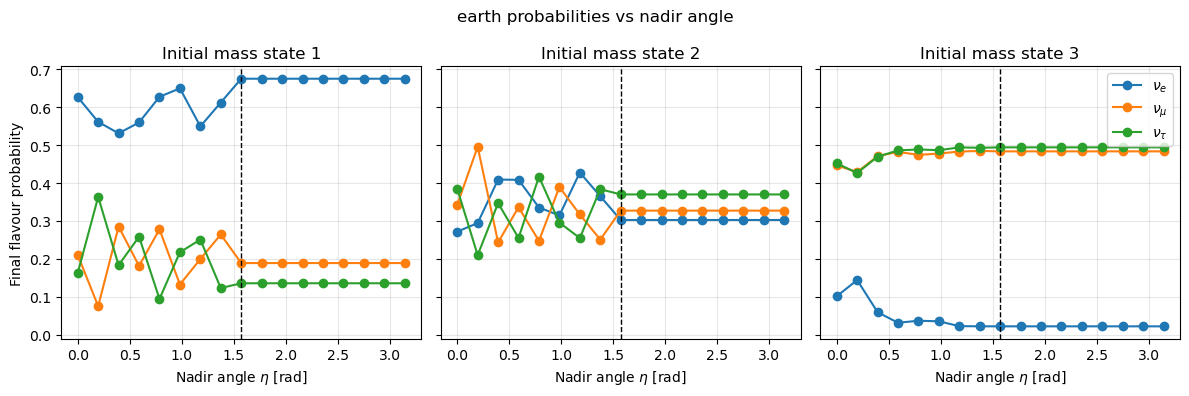

PASSED: plot_probabilities_vs_eta_for_mass_states()


In [10]:
run_notebook_call('plot_probabilities_vs_eta_for_mass_states()', lambda: TEST_MODULE.plot_probabilities_vs_eta_for_mass_states())


## Plot: `plot_energy_eta_probability_map()`

**What is checked:** Energy eta probability map behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_probability_energy_eta_map.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_energy_eta_probability_map()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_probability_energy_eta_map.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_energy_eta_probability_map() ...
Saved plot: V:\output\test\earth\test6_probabilities\plot_energy_eta_probability_map_figure_001.png


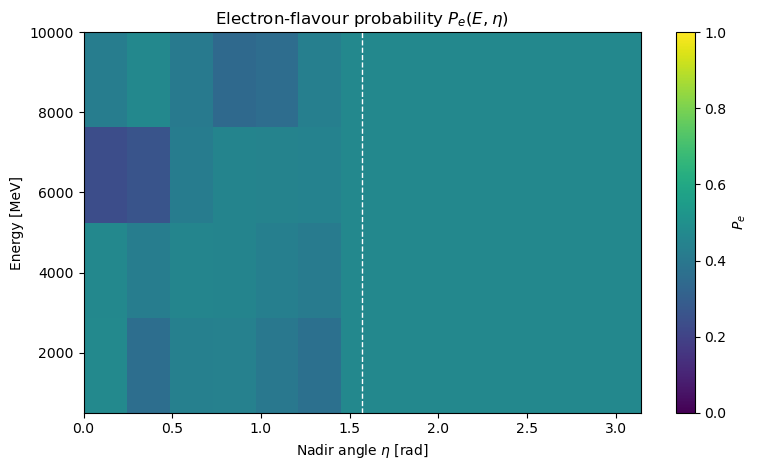

PASSED: plot_energy_eta_probability_map()


In [11]:
run_notebook_call('plot_energy_eta_probability_map()', lambda: TEST_MODULE.plot_energy_eta_probability_map())


## Plot: `plot_massbasis_vs_flavourbasis_example()`

**What is checked:** Massbasis vs flavourbasis example behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_probability_mass_vs_flavour_basis.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_massbasis_vs_flavourbasis_example()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_probability_mass_vs_flavour_basis.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_massbasis_vs_flavourbasis_example() ...
Saved plot: V:\output\test\earth\test6_probabilities\plot_massbasis_vs_flavourbasis_example_figure_001.png


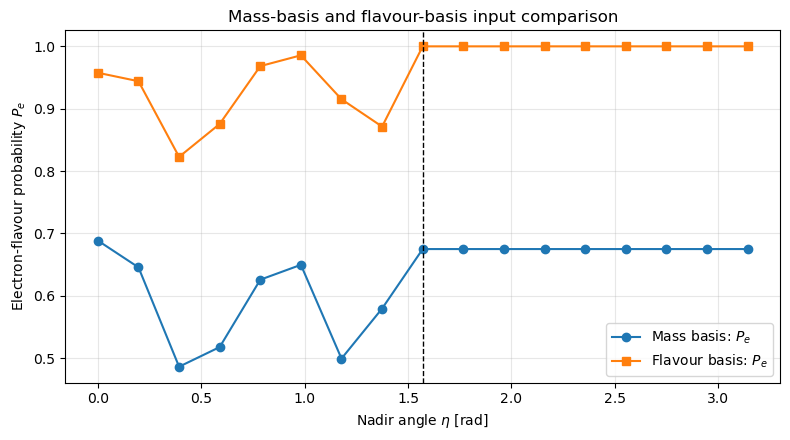

PASSED: plot_massbasis_vs_flavourbasis_example()


In [12]:
run_notebook_call('plot_massbasis_vs_flavourbasis_example()', lambda: TEST_MODULE.plot_massbasis_vs_flavourbasis_example())
